In [1]:
from sklearn.datasets import load_iris
import pandas as pd

data = load_iris(as_frame=True)
df = data.frame.copy()
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df['species'] = df['species'].map(dict(enumerate(data.target_names)))
df.to_csv('Iris.csv', index_label='Id')

print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


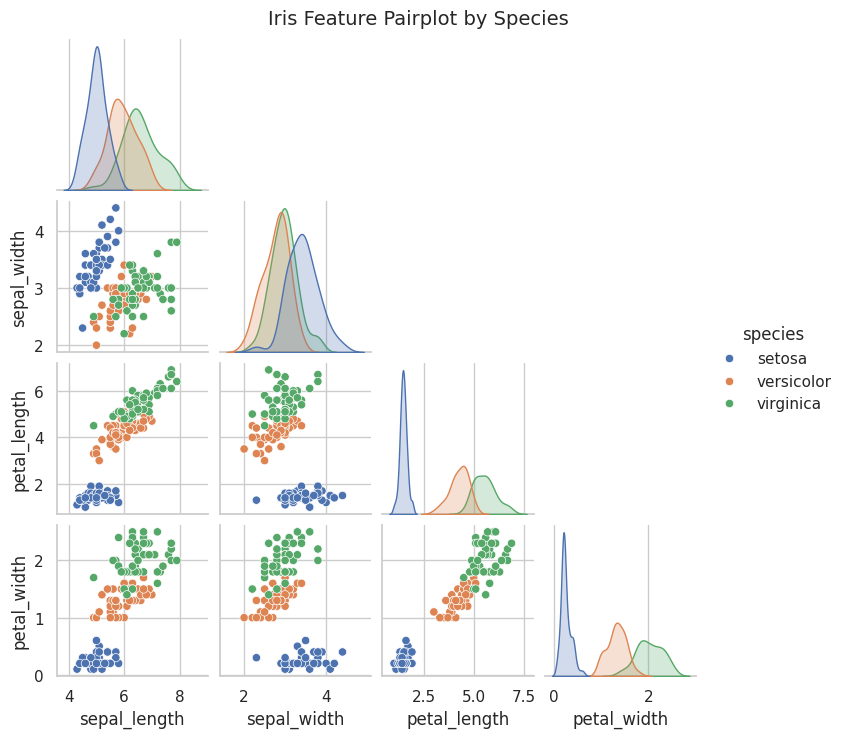

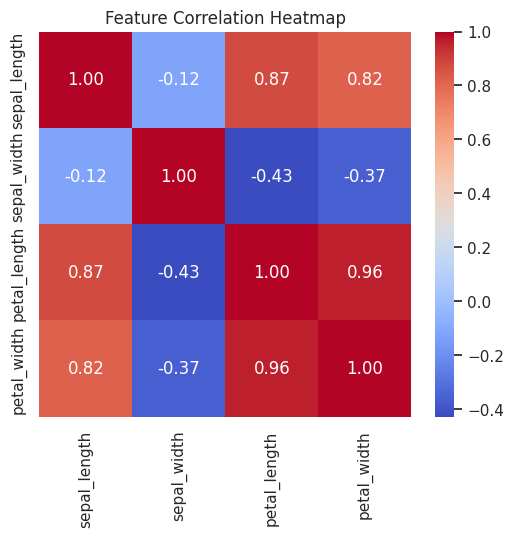

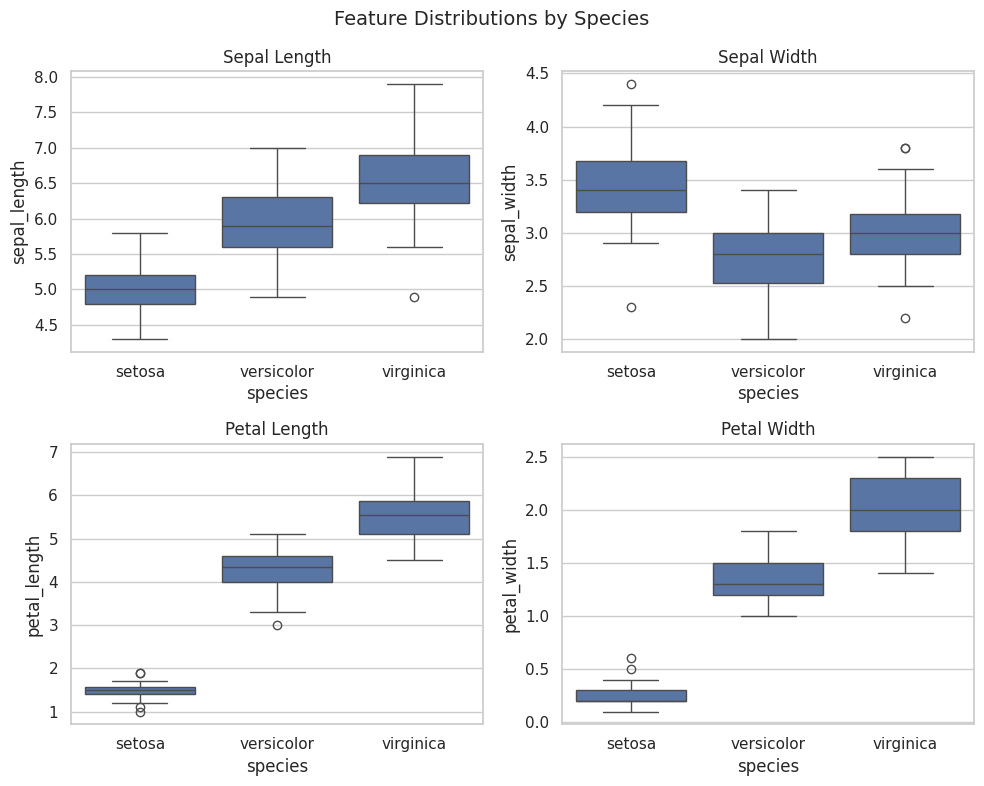

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

df = pd.read_csv("Iris.csv", index_col="Id")

print(df.describe())
print(df.isnull().sum())
print(df["species"].value_counts())

# Pairplot
pairplot = sns.pairplot(df, hue="species", corner=True, diag_kind="kde", palette="deep", height=1.8)
pairplot.fig.suptitle("Iris Feature Pairplot by Species", y=1.02, fontsize=14)
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df.drop(columns="species").corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.show()

# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x="species", y=feat, ax=ax)
    ax.set_title(feat.replace("_", " ").title())
fig.suptitle("Feature Distributions by Species", fontsize=14)
plt.tight_layout()
plt.show()

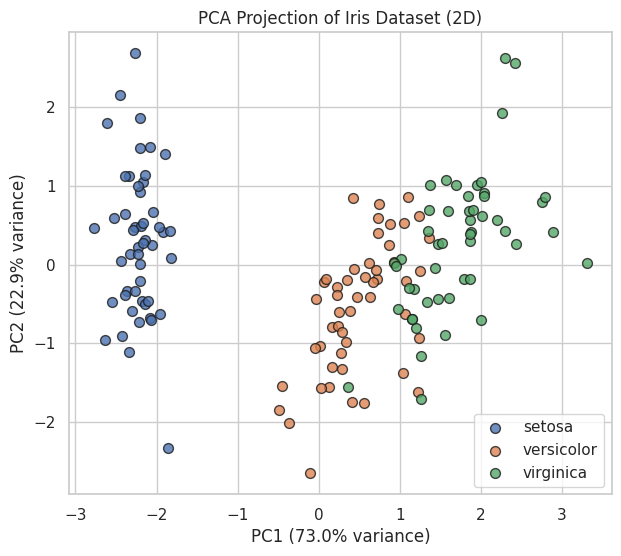

PC1+PC2 explain 95.81% of total variance


In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

X = df.drop(columns="species")
y = df["species"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_s = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_s)

fig, ax = plt.subplots(figsize=(7, 6))
for species in df["species"].unique():
    mask = (y == species).values
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=species, s=50, edgecolor="k", alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Projection of Iris Dataset (2D)")
ax.legend()
plt.show()

print(f"PC1+PC2 explain {sum(pca.explained_variance_ratio_)*100:.2f}% of total variance")

KNN                   : mean=0.9583  std=0.0264
Logistic Regression   : mean=0.9583  std=0.0264
SVM (RBF)             : mean=0.9667  std=0.0167
Decision Tree         : mean=0.9500  std=0.0167
Random Forest         : mean=0.9500  std=0.0312


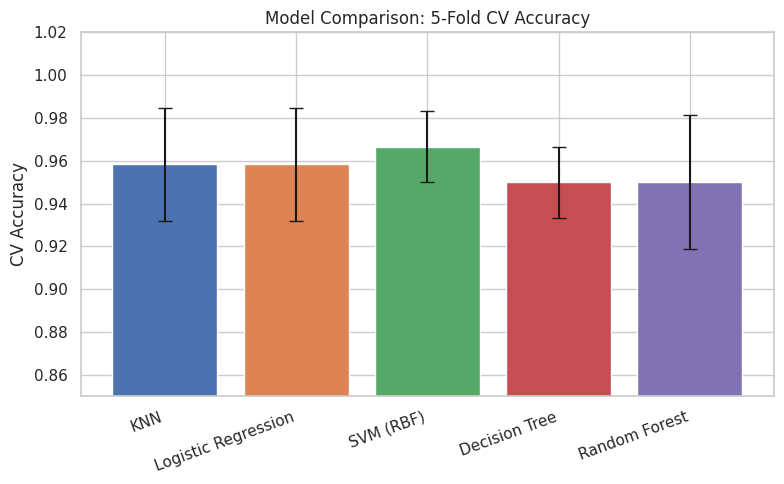

Best model: SVM (RBF)


In [4]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:22s}: mean={scores.mean():.4f}  std={scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
ax.bar(names, means, yerr=stds, capsize=5, color=sns.color_palette("deep", len(names)))
ax.set_ylabel("CV Accuracy")
ax.set_ylim(0.85, 1.02)
ax.set_title("Model Comparison: 5-Fold CV Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_model_name = max(results, key=lambda n: results[n].mean())
print("Best model:", best_model_name)

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear", "poly"],
}

grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy: 0.9750


Test accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



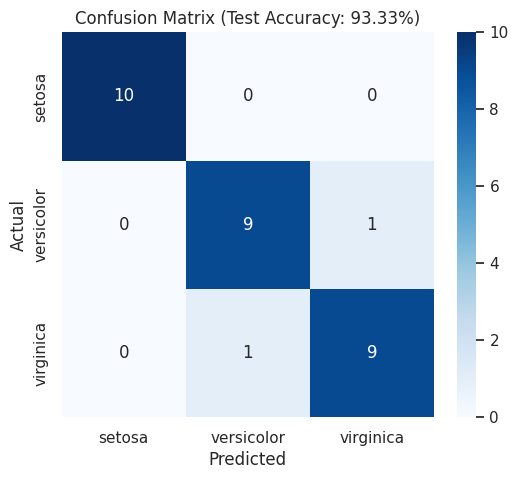

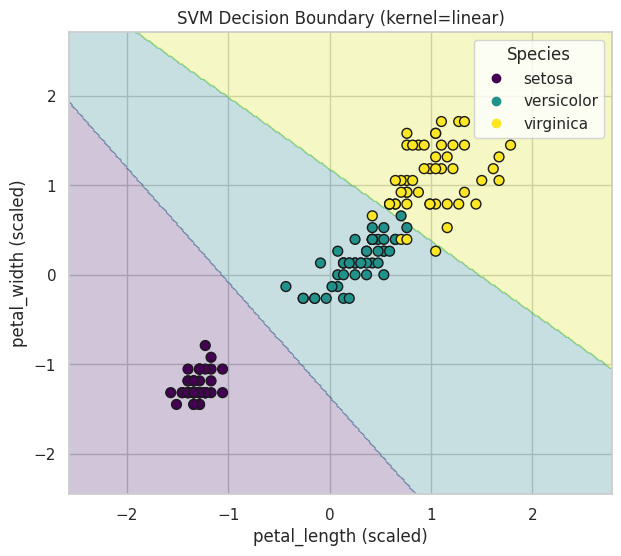

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred = best_model.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Test Accuracy: {test_acc:.2%})")
plt.show()

# Decision boundary on top 2 features
X_full = df[["petal_length", "petal_width"]].values
y_full = le.transform(df["species"])

scaler2 = StandardScaler()
X_full_s = scaler2.fit_transform(X_full)

boundary_model = SVC(**{k: v for k, v in grid.best_params_.items()})
boundary_model.fit(X_full_s, y_full)

x_min, x_max = X_full_s[:, 0].min() - 1, X_full_s[:, 0].max() + 1
y_min, y_max = X_full_s[:, 1].min() - 1, X_full_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = boundary_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="viridis")
scatter = ax.scatter(X_full_s[:, 0], X_full_s[:, 1], c=y_full, cmap="viridis", edgecolor="k", s=50)
handles, _ = scatter.legend_elements()
ax.legend(handles, le.classes_, title="Species")
ax.set_xlabel("petal_length (scaled)")
ax.set_ylabel("petal_width (scaled)")
ax.set_title(f"SVM Decision Boundary (kernel={grid.best_params_.get('kernel')})")
plt.show()